# AML23703 – Quantum Computing

## Tutorial 9: Bell States and Multi-Qubit Entanglement

**Name:** LAASYA S D

**USN:** 1GA23AI021

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 24-09-2026

# Objective

To understand Bell states and multi-qubit entanglement using quantum circuits and simulation. This tutorial focuses on constructing and measuring Bell states, studying their correlations in different measurement bases, understanding the conceptual role of entanglement in Quantum Key Distribution (QKD), and comparing the entanglement structures of GHZ and W states.

# Theory

Quantum entanglement is a phenomenon in which the state of two or more qubits cannot be described independently. The measurement results of entangled qubits can show strong correlations even when the qubits are considered as separate physical systems.

Bell states are the four maximally entangled two-qubit states:

\[
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

\[
|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}
\]

\[
|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}
\]

\[
|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}
\]

The \(\Phi^+\) Bell state can be created by applying a Hadamard gate to one qubit followed by a CNOT gate. When measured in the computational basis, it produces correlated outcomes `00` and `11`.

Bell-state correlations can also be studied by changing the measurement basis. Entanglement is important in quantum communication protocols such as Quantum Key Distribution (QKD).

For multiple qubits, states such as the GHZ state and W state demonstrate different forms of multipartite entanglement. Studying what happens when one qubit is measured or traced out helps us understand the structure and behaviour of these states.

# Exercise 1: Easy

## Question

Construct the \(\Phi^+\) Bell state and confirm through 1024-shot simulation that only `00` and `11` outcomes occur.

## Aim

To construct the \(\Phi^+\) Bell state using quantum gates and verify its correlated measurement outcomes using a 1024-shot simulation.

## Theory

The \(\Phi^+\) Bell state is:

\[
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

It can be constructed by starting with two qubits in the \(|00\rangle\) state. A Hadamard gate is applied to the first qubit to create a superposition. A CNOT gate is then applied to entangle the two qubits.

The resulting state is:

\[
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

When measured in the computational basis, the expected outcomes are only `00` and `11`.

Phi+ Bell State Circuit:


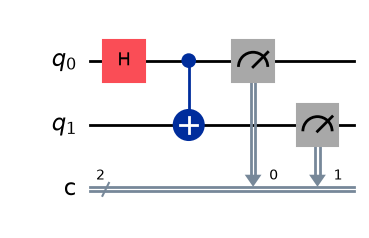

Measurement Results:
{'11': 492, '00': 532}


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Create a 2-qubit circuit with 2 classical bits
qc = QuantumCircuit(2, 2)

# Create the Phi+ Bell state
qc.h(0)
qc.cx(0, 1)

# Measure both qubits
qc.measure([0, 1], [0, 1])

# Display the circuit
print("Phi+ Bell State Circuit:")
display(qc.draw("mpl"))

# Simulate the circuit
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()

# Get measurement results
counts = result.get_counts()

print("Measurement Results:")
print(counts)

## Observation

The 1024-shot simulation produced only the measurement outcomes `00` and `11`. Both outcomes occurred with approximately equal frequency.

The outcomes `01` and `10` were not observed. This confirms the strong correlation between the two qubits in the \(\Phi^+\) Bell state.

## Visualization

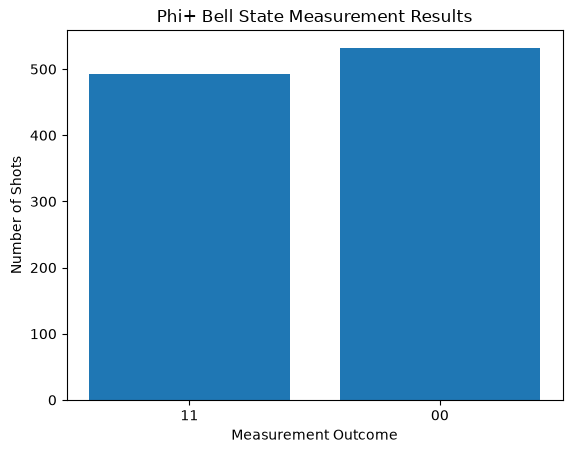

In [2]:
# Plot the measurement results
plt.bar(counts.keys(), counts.values())

plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Phi+ Bell State Measurement Results")

plt.show()

## Conclusion

The \(\Phi^+\) Bell state was successfully constructed using a Hadamard gate and a CNOT gate. The 1024-shot simulation produced only `00` and `11` outcomes, confirming the expected correlation between the two entangled qubits.

# Exercise 2: Medium

## Question

Construct all four Bell states and tabulate the measurement outcome distributions for comparison.

## Aim

To construct the four Bell states and compare their measurement outcomes using quantum circuit simulation.

## Theory

There are four Bell states:

\[
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

\[
|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}
\]

\[
|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}
\]

\[
|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}
\]

The Bell states differ in their relative phase and in whether the measurement results are correlated or anti-correlated.

For the \(\Phi\) states, the computational-basis outcomes are `00` and `11`.

For the \(\Psi\) states, the computational-basis outcomes are `01` and `10`.

The relative phase between the terms cannot be directly distinguished using computational-basis measurement alone, but it becomes important when other measurement bases are used.

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pandas as pd

simulator = AerSimulator()
shots = 1024

# Function to create Bell states
def create_bell_state(state):
    qc = QuantumCircuit(2, 2)

    # Create Phi+ first
    qc.h(0)
    qc.cx(0, 1)

    if state == "Phi-":
        qc.z(0)

    elif state == "Psi+":
        qc.x(1)

    elif state == "Psi-":
        qc.x(1)
        qc.z(0)

    qc.measure([0, 1], [0, 1])

    return qc


# Store measurement results
results = {}

for state in ["Phi+", "Phi-", "Psi+", "Psi-"]:
    qc = create_bell_state(state)

    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    results[state] = counts

# Display the results
print("Bell State Measurement Results:")
for state, counts in results.items():
    print(state, ":", counts)

Bell State Measurement Results:
Phi+ : {'00': 516, '11': 508}
Phi- : {'00': 493, '11': 531}
Psi+ : {'01': 517, '10': 507}
Psi- : {'01': 534, '10': 490}


In [4]:
# Create a comparison table
rows = []

for state, counts in results.items():
    rows.append({
        "Bell State": state,
        "00": counts.get("00", 0),
        "01": counts.get("01", 0),
        "10": counts.get("10", 0),
        "11": counts.get("11", 0)
    })

table = pd.DataFrame(rows)

display(table)

,Bell State,00,01,10,11
0,Phi+,516,0,0,508
1,Phi-,493,0,0,531
2,Psi+,0,517,507,0
3,Psi-,0,534,490,0


## Observation

The four Bell states showed two distinct measurement patterns.

The \(\Phi^+\) and \(\Phi^-\) states produced only `00` and `11`, while the \(\Psi^+\) and \(\Psi^-\) states produced only `01` and `10`.

The results were approximately equally distributed between the two possible outcomes for each Bell state. Although \(\Phi^+\) and \(\Phi^-\) have different relative phases, their computational-basis measurement distributions are the same. Similarly, \(\Psi^+\) and \(\Psi^-\) have the same computational-basis distribution.

## Visualization

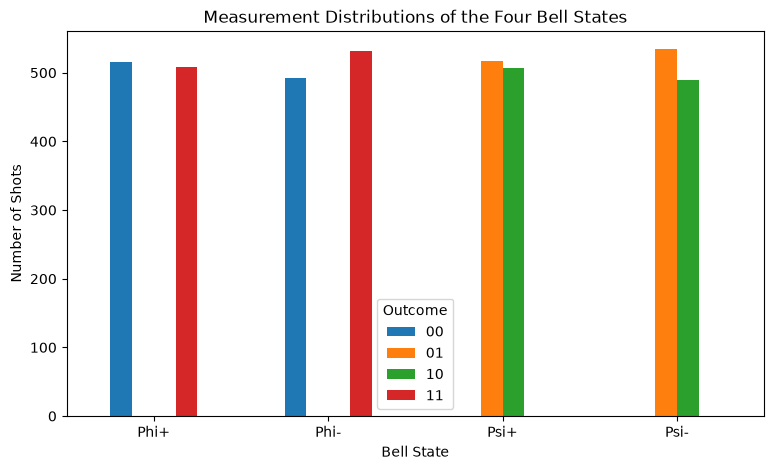

In [5]:
import matplotlib.pyplot as plt

# Plot Bell state measurement distributions
table.plot(
    x="Bell State",
    y=["00", "01", "10", "11"],
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Bell State")
plt.ylabel("Number of Shots")
plt.title("Measurement Distributions of the Four Bell States")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.show()

## Conclusion

All four Bell states were successfully constructed and measured. The \(\Phi\) states produced correlated computational-basis outcomes (`00` and `11`), while the \(\Psi\) states produced anti-correlated outcomes (`01` and `10`). The experiment demonstrates the different correlation structures of the four maximally entangled Bell states.

# Exercise 3: Hard

## Question

Measure a Bell pair in the Hadamard basis instead of the computational basis and explain the resulting correlation pattern.

## Aim

To measure the \(\Phi^+\) Bell state in the Hadamard basis and observe how the entangled qubits remain correlated.

## Theory

The computational basis consists of the states \(|0\rangle\) and \(|1\rangle\). The Hadamard basis, also called the \(X\)-basis, consists of:

\[
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
\]

\[
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
\]

A Hadamard gate applied immediately before measurement changes the measurement basis from the computational basis to the Hadamard basis.

For the \(\Phi^+\) Bell state,

\[
|\Phi^+\rangle =
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

measuring both qubits in the Hadamard basis produces correlated results. The expected outcomes are `00` and `11`, while `01` and `10` should not occur ideally.

This demonstrates that the correlation of an entangled state is not limited to a single measurement basis.

Bell Pair Measured in Hadamard Basis:


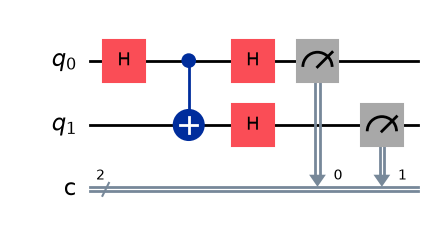

Measurement Results:
{'11': 515, '00': 509}


In [6]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Create the Phi+ Bell state
qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

# Change to the Hadamard basis before measurement
qc.h(0)
qc.h(1)

# Measure both qubits
qc.measure([0, 1], [0, 1])

# Display the circuit
print("Bell Pair Measured in Hadamard Basis:")
display(qc.draw("mpl"))

# Simulate
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()

counts_h = result.get_counts()

print("Measurement Results:")
print(counts_h)

## Observation

When the \(\Phi^+\) Bell state was measured in the Hadamard basis, the results were still correlated. The simulation produced only `00` and `11` outcomes, with approximately equal frequencies.

The outcomes `01` and `10` were not observed. This shows that the \(\Phi^+\) Bell state maintains its correlation when both qubits are measured in the same Hadamard basis.

## Visualization

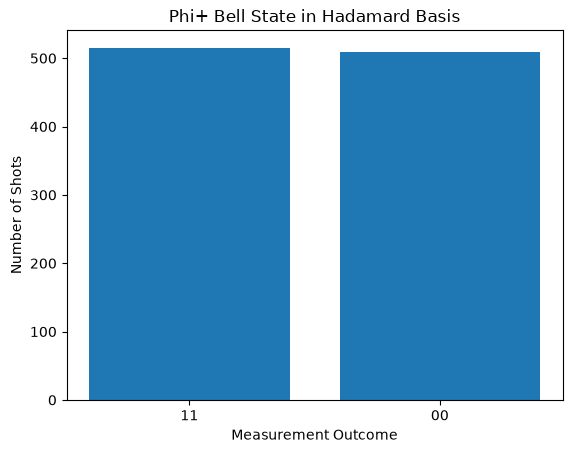

In [7]:
# Plot Hadamard-basis measurement results
plt.bar(counts_h.keys(), counts_h.values())

plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Phi+ Bell State in Hadamard Basis")

plt.show()

## Conclusion

The \(\Phi^+\) Bell state was successfully measured in the Hadamard basis. The results remained correlated, with only `00` and `11` appearing in the simulation. This demonstrates that entanglement can produce strong correlations when both qubits are measured in the same basis.

# Exercise 4: Real-World

## Question

Relate Bell-state correlations conceptually to Quantum Key Distribution (QKD) and prepare a short explanation of how entanglement could secure a communication channel.

## Aim

To understand how the correlations of entangled Bell pairs can be used conceptually in Quantum Key Distribution (QKD) to detect eavesdropping and support secure communication.

## Theory

Quantum Key Distribution is a method of securely sharing cryptographic keys using quantum properties.

Entanglement-based QKD protocols, such as the E91 protocol, use pairs of entangled particles shared between two communicating parties. The parties measure their particles using selected measurement bases and compare some of their results.

When the measurements are performed under the expected conditions, entangled particles produce characteristic correlations. An eavesdropper attempting to intercept or measure the quantum particles can disturb these correlations.

By checking a subset of the measurement results, the communicating parties can estimate whether the quantum channel has been disturbed. A significant unexpected change in the observed correlations can indicate the presence of interference or eavesdropping.

Therefore, Bell-state correlations provide a conceptual foundation for detecting disturbances in an entanglement-based quantum communication system.

## Visualization

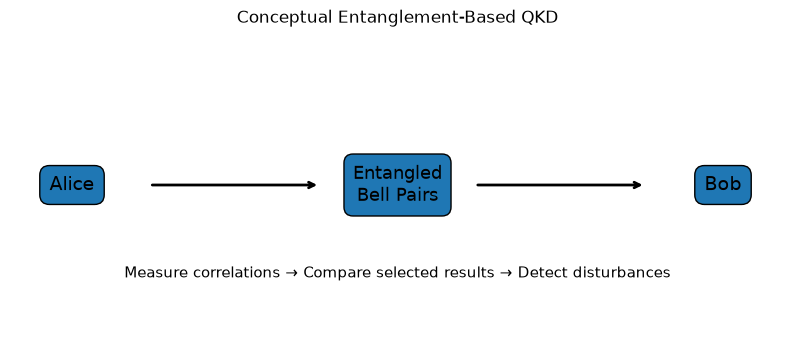

In [8]:
import matplotlib.pyplot as plt

# Simple conceptual representation of an entanglement-based QKD system

fig, ax = plt.subplots(figsize=(10, 4))

ax.text(0.08, 0.5, "Alice", ha="center", va="center",
        fontsize=14, bbox=dict(boxstyle="round,pad=0.5"))

ax.text(0.92, 0.5, "Bob", ha="center", va="center",
        fontsize=14, bbox=dict(boxstyle="round,pad=0.5"))

ax.text(0.50, 0.5, "Entangled\nBell Pairs", ha="center", va="center",
        fontsize=13, bbox=dict(boxstyle="round,pad=0.5"))

ax.annotate("", xy=(0.40, 0.5), xytext=(0.18, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.annotate("", xy=(0.82, 0.5), xytext=(0.60, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.50, 0.20,
        "Measure correlations → Compare selected results → Detect disturbances",
        ha="center", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.title("Conceptual Entanglement-Based QKD")
plt.show()

## Observation

Bell-state entanglement provides correlated measurement results between the two communicating parties. In an entanglement-based QKD system, these correlations can be checked to determine whether the quantum communication channel has been disturbed.

An eavesdropper's interaction with the quantum system can alter the expected measurement statistics. Therefore, observing the correlations allows the communicating parties to detect possible interference with the quantum channel.

## Conclusion

Bell-state correlations can be used conceptually in entanglement-based QKD to support secure communication. By comparing selected measurement results, the communicating parties can detect disturbances in the quantum channel. This demonstrates how a fundamental property of entanglement can be applied to quantum communication and security.

# Exercise 5: Challenge

## Question

Implement a 3-qubit GHZ state and a 3-qubit W-state, and compare their entanglement structure by examining the behaviour when one qubit is measured or traced out.

## Aim

To construct GHZ and W states and study how their entanglement changes when one qubit is measured.

## Theory

The 3-qubit GHZ state is:

\[
|GHZ\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}
\]

The GHZ state can be created by applying a Hadamard gate to the first qubit followed by CNOT gates from the first qubit to the other two qubits.

The 3-qubit W state is:

\[
|W\rangle = \frac{|001\rangle + |010\rangle + |100\rangle}{\sqrt{3}}
\]

The GHZ and W states represent different structures of three-qubit entanglement.

For the GHZ state, measuring one qubit in the computational basis causes the other two qubits to collapse to either `00` or `11`. The remaining pair is then no longer in a two-qubit entangled state.

For the W state, measuring one qubit can leave the other two qubits in an entangled state for one of the measurement outcomes. This shows that the W state distributes entanglement differently from the GHZ state.

GHZ State Circuit:


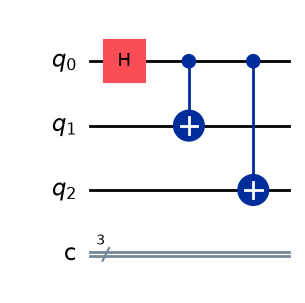

GHZ Measurement Results:
{'000': 525, '111': 499}

W State Circuit:


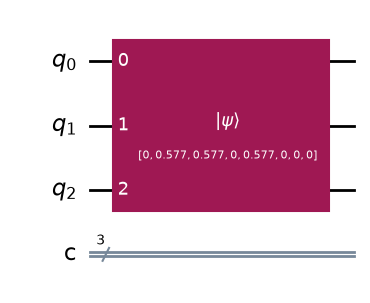

W State Measurement Results:
{'010': 339, '001': 330, '100': 355}


In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()

# -------------------------
# GHZ STATE
# -------------------------

ghz = QuantumCircuit(3, 3)

ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)

print("GHZ State Circuit:")
display(ghz.draw("mpl"))

# Measure all qubits
ghz.measure([0, 1, 2], [0, 1, 2])

result_ghz = simulator.run(ghz, shots=1024).result()
ghz_counts = result_ghz.get_counts()

print("GHZ Measurement Results:")
print(ghz_counts)


# -------------------------
# W STATE
# -------------------------

w = QuantumCircuit(3, 3)

# Prepare the W state
w.initialize(
    [
        0,
        1 / np.sqrt(3),
        1 / np.sqrt(3),
        0,
        1 / np.sqrt(3),
        0,
        0,
        0
    ],
    [0, 1, 2]
)

print("\nW State Circuit:")
display(w.draw("mpl"))

# Measure all qubits
w.measure([0, 1, 2], [0, 1, 2])

result_w = simulator.run(w, shots=1024).result()
w_counts = result_w.get_counts()

print("W State Measurement Results:")
print(w_counts)

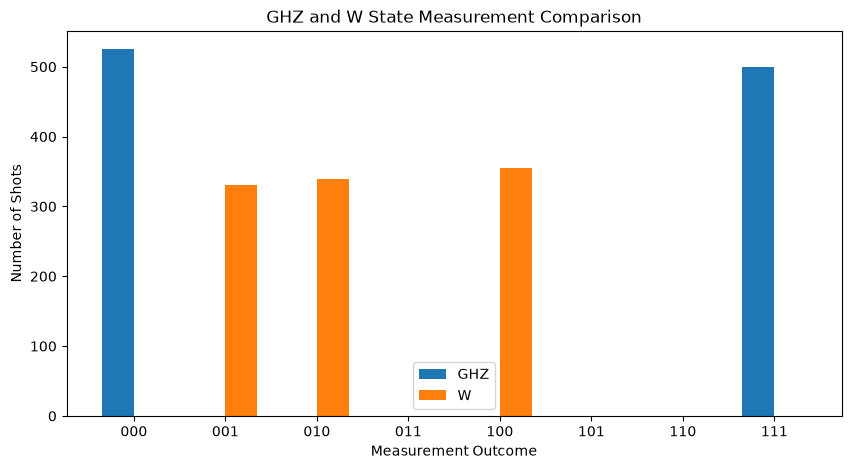

In [10]:
# Combine the measurement results for comparison

all_outcomes = ["000", "001", "010", "011", "100", "101", "110", "111"]

ghz_values = [ghz_counts.get(x, 0) for x in all_outcomes]
w_values = [w_counts.get(x, 0) for x in all_outcomes]

x = np.arange(len(all_outcomes))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width / 2, ghz_values, width, label="GHZ")
plt.bar(x + width / 2, w_values, width, label="W")

plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("GHZ and W State Measurement Comparison")
plt.xticks(x, all_outcomes)
plt.legend()

plt.show()

## Measuring One Qubit

For the GHZ state,

\[
|GHZ\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}
\]

measuring the third qubit gives either:

- `0` → remaining two qubits become `|00⟩`
- `1` → remaining two qubits become `|11⟩`

Thus, after the measurement, the remaining two qubits are no longer in a two-qubit entangled Bell state.

For the W state,

\[
|W\rangle = \frac{|001\rangle + |010\rangle + |100\rangle}{\sqrt{3}}
\]

measuring the third qubit gives:

- `1` → remaining two qubits become `|00⟩`
- `0` → remaining two qubits become an entangled state proportional to \(|01⟩ + |10⟩\)

Therefore, the W state can retain bipartite entanglement after one qubit is measured, demonstrating a different type of multipartite entanglement from the GHZ state.

## Observation

The GHZ state produced only `000` and `111` when all three qubits were measured, showing strong three-qubit correlations.

The W state produced `001`, `010`, and `100`, with approximately equal probabilities.

When one qubit of the GHZ state is measured in the computational basis, the remaining two qubits collapse to `00` or `11` and no longer form an entangled Bell pair.

For the W state, measuring one qubit can leave the other two qubits in an entangled state. This demonstrates that the W state has a different and more distributed entanglement structure.

## Conclusion

The 3-qubit GHZ and W states were successfully constructed and simulated. The GHZ state showed strong three-qubit correlations, while the W state showed a different distribution of excitation across the three qubits.

The behaviour after measuring one qubit demonstrated an important difference between the two states. The GHZ state's remaining qubits lose their entanglement after a computational-basis measurement, whereas the W state can retain bipartite entanglement. This highlights the different structures of multipartite quantum entanglement.

# Reflection Questions

## 1. Why can neither qubit of a Bell pair be described by an independent state vector?

A Bell pair is an entangled quantum system, so the state of the complete two-qubit system must be described jointly. The individual qubits do not have independent pure-state descriptions that completely determine the state of the pair.

For example, the \(\Phi^+\) state is:

\[
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

The state describes a relationship between both qubits rather than two independent states. Measuring one qubit changes the state of the other qubit because their outcomes are correlated through entanglement.

## 2. In what way does entanglement differ fundamentally from classical statistical correlation?

Classical statistical correlation can generally be explained using pre-existing classical variables and does not require the joint system to be in a quantum superposition.

Quantum entanglement is a property of the joint quantum state. Entangled systems can exhibit correlations that cannot be reproduced by a classical description based only on independent local states and shared classical randomness. Bell-state measurements demonstrate these quantum correlations through different measurement bases.

# Overall Conclusion

The tutorial demonstrated the construction and measurement of Bell states and the study of multi-qubit entanglement. The \(\Phi^+\) Bell state produced correlated `00` and `11` outcomes, while the four Bell states showed different correlation patterns.

Measurement in the Hadamard basis demonstrated that entanglement can maintain correlations across different measurement bases. The conceptual QKD exercise showed how entanglement correlations can be used to detect disturbances in a quantum communication channel.

Finally, the GHZ and W states demonstrated different structures of multipartite entanglement. Studying the effect of measuring one qubit showed that GHZ and W states behave differently when part of the system is removed or measured.